### Import dependencies

In [1]:
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy import constants as c

import sys
sys.path.append('../')
from Functions.queryGrid import *

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


### Download Data

In [2]:
data = pd.read_csv('Target EBs Data.txt', sep=" ")
data['Target'] = data['Target'].astype(str).str[4:]
data['Depth_diff'] = data['Depth1'] - data['Depth2']
data['Width_diff'] = data['Width1'] - data['Width2']
data

,Index,Target,Period,Width1,Width2,Depth1,Depth2,Depth_diff,Width_diff
0,10,364325969,0.419969,0.390720,0.392342,0.414410,0.392728,0.021682,-0.001623
1,15,140757590,0.418107,0.404579,0.417147,0.378855,0.350413,0.028442,-0.012568
2,30,177258700,0.688000,0.397516,0.433229,0.435879,0.400225,0.035654,-0.035713
3,62,349480507,3.124534,0.088510,0.088611,0.379399,0.379335,0.000064,-0.000101
4,75,33715938,2.876839,0.072020,0.070742,0.342318,0.344474,-0.002155,0.001279
5,77,149629043,2.188053,0.073520,0.073902,0.387873,0.367827,0.020046,-0.000382
6,103,294273900,0.472023,0.344468,0.353623,0.355571,0.335145,0.020426,-0.009155
7,105,157175641,0.370090,0.335582,0.336142,0.399255,0.389412,0.009843,-0.000560
8,117,382266319,0.344076,0.387365,0.368452,0.480898,0.440441,0.040457,0.018913
9,120,231093356,3.470085,0.061867,0.061638,0.412312,0.386459,0.025853,0.000229


In [3]:
gaiaQuery = queryGaia(data['Target'].to_list(), DR=3)
gaiaQuery.insert(2, 'Index', data['Index'])
gaiaQuery.insert(3, 'Period', data['Period'])
gaiaQuery['Expected Mag'] = 5 + gaiaQuery['Gaia3_G'] - 5*np.log10(gaiaQuery['Gaia3_dist'])
gaiaQuery = gaiaQuery[gaiaQuery['Gaia3_T'].between(4000, 7000, inclusive='both')].reset_index(drop=True)
gaiaQuery = Gaia3ToJohnson(gaiaQuery)
gaiaQuery

,Gaia3_id,TIC_id,Index,Period,Gaia3_parallax,Gaia3_dist,Gaia3_G,Gaia3_T,bp_rp,bp_rp_err,Expected Mag,b_v,b_v_err
0,1861738069358924672,364325969,10,0.419969,2.988455,334.621048,9.594584,6411.373047,0.603031,0.001873,1.971817,0.513012,0.0659
1,2054756957652357888,349480507,62,3.124534,4.007291,249.545138,8.241514,6953.510254,0.453519,0.000727,1.255769,0.384116,0.0659
2,2076286902851413376,149629043,77,2.188053,1.161896,860.661963,11.775440,6004.518066,0.713685,0.000914,2.101277,0.611595,0.0659
3,2078036917346313088,294273900,103,0.472023,1.070901,933.793430,11.885704,6142.465332,0.697337,0.035443,2.034450,0.596909,0.0659
4,2078152091187852288,157175641,105,0.370090,0.398152,2511.601398,14.866896,5676.295898,0.868471,0.001791,2.867142,0.751839,0.0659
5,2083993762113117952,382266319,117,0.344076,2.515213,397.580702,9.779630,6965.870117,0.631768,0.000563,1.782503,0.538408,0.0659
6,2099544876609720576,231093356,120,3.470085,1.491084,670.652807,12.088227,6276.393555,0.682956,0.029773,2.955738,0.584019,0.0659
7,2100618270538909056,348897766,207,0.442000,1.944204,514.349331,11.926363,5900.007324,0.730266,0.000961,3.370072,0.626524,0.0659
8,2105645615655449728,165458777,210,0.292921,1.719149,581.683298,12.587934,5620.080078,0.836153,0.040204,3.764500,0.722446,0.0659
9,2138551219835016320,158713903,238,3.592526,24.708961,40.471147,5.778308,6403.595703,0.608405,0.002468,2.742580,0.517748,0.0659


### Retrieving spectral types

In [4]:
def querySimbad(tic_ids):
    Simbad.add_votable_fields('sp_type')
    
    formatted_ids = [f'TIC {int(tid)}' for tid in tic_ids]
    results = Simbad.query_objects(formatted_ids)
    
    if results is None:
        print("No results found")
        return None
    
    df = results.to_pandas()
    df.insert(1, 'TIC_id', tic_ids)
    
    df['sp_type'] = df['sp_type'].replace(r'^\s*$', np.nan, regex=True)
    df = df.dropna(subset=['sp_type'])
            
    return df[['main_id', 'TIC_id', 'sp_type']]

spectral_df = querySimbad(gaiaQuery['TIC_id'].to_list())
spectral_df.insert(0, 'Index', gaiaQuery['Index'])
spectral_df['T_eff'] = gaiaQuery['Gaia3_T']
spectral_df

,Index,main_id,TIC_id,sp_type,T_eff
3,103,V* V604 Car,294273900,F7IV/V,6142.465332
4,105,V* V752 Cen,157175641,F7/G0(V),5676.295898
6,120,HD 270567,231093356,K0,6276.393555
11,262,V* UY Vir,452734608,A7V,6394.448242
12,287,V* NT Vel,118313102,B6V(n),6077.103516
13,298,V* UX Men,141268467,F8V,5809.639648
14,300,V* X Car,89787778,A0Vn,6006.727051
18,509,V* OU Lup,75969405,B9IV,6150.506348
21,816,V* V4403 Sgr,211215485,F3V,6242.131348
23,871,TYC 3124-1003-1,121273032,sd:F6,6299.718750


### Fitting to best config

In [5]:
all_grids = queryPrimary(gaiaQuery, filepath='binarystargrid.db')

final_results = []

for target_id, grid in all_grids.items():
    obs = data[data['Target'] == target_id].iloc[0]
    best_fit = querySecondary(pd.DataFrame(grid), obs['Depth_diff'], obs['Width_diff'], depth_format='absolute', width_format='absolute', primary_width=obs['Width1'])
    best_fit['Target'] = target_id
    final_results.append(best_fit)
    
df_final = pd.concat(final_results).reset_index(drop=True)
df_final['Index'] = gaiaQuery['Index']
df_final['Period'] = gaiaQuery['Period']
df_final['Dist'] = gaiaQuery['Gaia3_dist']
df_final['Actual SpT'] = spectral_df['sp_type']
df_final['b_v'] = gaiaQuery['b_v']

df_final = df_final.drop(columns=['Primary B-V', 'Primary BP-RP', 'Depth Difference', 'Width Difference']).reset_index(drop=True)
df_final = df_final[df_final['Primary SpT'] == df_final['Secondary SpT']]

# Temp calculations for comparison
df_final['Ballesteros T'] = 4600 * ((0.92 * df_final['b_v'] + 1.7)**-1 + (0.92 * df_final['b_v'] + 0.62)**-1)

casgrandePoly = np.poly1d([-0.0060, 0.4809, 0.5665])
df_final['Casgrande T'] = 5040 * (0.5665 + 0.4809 * df_final['b_v'] - 0.0060 * df_final['b_v']**2)**-1
df_final['Huang T'] = 5040 * (0.63421 + 0.30538 * df_final['b_v'] + 0.12308 * df_final['b_v']**2)**-1

df_final

,Primary SpT,Primary T,Primary R,Primary M,Secondary SpT,Secondary T,Secondary R,Secondary M,Target,Index,Period,Dist,Actual SpT,b_v,Ballesteros T,Casgrande T,Huang T
0,F7,6280.0,1.324,1.210,F7,6280.0,1.324,1.210,364325969,10,0.419969,334.621048,NaN,0.513012,6330.457853,6209.738449,6121.958420
1,F5,6550.0,1.473,1.330,F5,6550.0,1.473,1.330,349480507,62,3.124534,249.545138,NaN,0.384116,6965.968459,6716.988813,6548.250011
2,G1,5860.0,1.060,1.030,G1,5860.0,1.060,1.030,149629043,77,2.188053,860.661963,NaN,0.611595,5922.511687,5871.582007,5813.036494
3,G0,5930.0,1.100,1.060,G0,5930.0,1.100,1.060,294273900,103,0.472023,933.793430,F7IV/V,0.596909,5979.673779,5919.553352,5858.098873
4,G8,5480.0,0.914,0.940,G8,5480.0,0.914,0.940,157175641,105,0.370090,2511.601398,F7/G0(V),0.751839,5430.244857,5450.605289,5399.734789
6,G0,5930.0,1.100,1.060,G0,5930.0,1.100,1.060,231093356,120,3.470085,670.652807,K0,0.584019,6030.828569,5962.321098,5897.925625
8,G8,5480.0,0.914,0.940,G8,5480.0,0.914,0.940,165458777,210,0.292921,581.683298,NaN,0.722446,5526.060865,5533.641618,5483.807856
9,F8,6180.0,1.221,1.180,F8,6180.0,1.221,1.180,158713903,238,3.592526,40.471147,NaN,0.517748,6309.475935,6192.584791,6106.773544
11,F7,6280.0,1.324,1.210,F7,6280.0,1.324,1.210,452734608,262,3.992123,625.065617,A7V,0.494278,6414.952144,6278.553581,6182.360576
12,G4,5680.0,0.991,0.985,G4,5680.0,0.991,0.985,118313102,287,9.261700,316.808199,B6V(n),0.668491,5711.692768,5693.011557,5641.649820


In [6]:
# Create table
df_lum = df_final[['Target', 'Index', 'Dist', 'Period', 'b_v', 'Ballesteros T']].copy()
df_lum = df_lum.merge(data[['Target', 'Depth1', 'Depth2', 'Width1', 'Width2']], on='Target', how='left')

df_lum['M'] = -0.964 + (3.475 * 10**-4) * df_lum['Ballesteros T'] # masses in solar masses
df_lum['a'] = ((c.GM_sun * df_lum['M']) / (2 * np.pi**2) * (df_lum['Period'] * 24 * 60**2)**2)**(1/3) # semi-major axis in metres
df_lum['v'] = 2 * np.pi * df_lum['a'] / (df_lum['Period'] * 24 * 60**2) # velocity in m/s

df_lum['R1'] = (df_lum['Width1'] * 24 * 60**2) * df_lum['v'] / 2 # radii in m
df_lum['R2'] = (df_lum['Width2'] * 24 * 60**2) * df_lum['v'] / 2

df_lum['L1'] = 4 * np.pi * df_lum['R1']**2 * c.sigma_sb * df_lum['Ballesteros T']**4 # luminonisty in W
df_lum['L2'] = 4 * np.pi * df_lum['R2']**2 * c.sigma_sb * df_lum['Ballesteros T']**4

df_lum['m'] = 4.74 - 2.5 * np.log10((df_lum['L1'] + df_lum['L2'])/c.L_sun) # scaled from L/L_odot

df_lum

,Target,Index,Dist,Period,b_v,Ballesteros T,Depth1,Depth2,Width1,Width2,M,a,v,R1,R2,L1,L2,m
0,364325969,10,334.621048,0.419969,0.513012,6330.457853,0.414410,0.392728,0.390720,0.392342,1.235834,2.219907e+09,384400.092568,6.488327e+09,6.515271e+09,4.817564e+28,4.857659e+28,-1.266723
1,349480507,62,249.545138,3.124534,0.384116,6965.968459,0.379399,0.379335,0.088510,0.088611,1.456674,8.936773e+09,207999.184531,7.953144e+08,7.962212e+08,1.061268e+27,1.063690e+27,2.879054
2,149629043,77,860.661963,2.188053,0.611595,5922.511687,0.387873,0.367827,0.073520,0.073902,1.094073,6.406052e+09,212911.287852,6.762205e+08,6.797337e+08,4.008870e+26,4.050633e+26,3.931659
3,294273900,103,933.793430,0.472023,0.596909,5979.673779,0.355571,0.335145,0.344468,0.353623,1.113937,2.318100e+09,357137.137509,5.314559e+09,5.455808e+09,2.573156e+28,2.711750e+28,-0.610163
4,157175641,105,2511.601398,0.370090,0.751839,5430.244857,0.399255,0.389412,0.335582,0.336142,0.923010,1.851301e+09,363777.209927,5.273730e+09,5.282530e+09,1.723197e+28,1.728953e+28,-0.147794
5,231093356,120,670.652807,3.470085,0.584019,6030.828569,0.412312,0.386459,0.061867,0.061638,1.131713,8.810663e+09,184643.766933,4.934860e+08,4.916593e+08,2.295510e+26,2.278547e+26,4.546676
6,165458777,210,581.683298,0.292921,0.722446,5526.060865,0.431508,0.422343,0.365345,0.363532,0.956306,1.602886e+09,397940.288571,6.280655e+09,6.249493e+09,2.621164e+28,2.595218e+28,-0.595994
7,158713903,238,40.471147,3.592526,0.517748,6309.475935,0.453861,0.445444,0.094714,0.093963,1.228543,9.266873e+09,187585.549127,7.675319e+08,7.614493e+08,6.652542e+26,6.547519e+26,3.395990
8,452734608,262,625.065617,3.992123,0.494278,6414.952144,0.497486,0.504190,0.081710,0.081589,1.265196,1.003980e+10,182888.844413,6.455754e+08,6.446188e+08,5.029088e+26,5.014195e+26,3.692741
9,118313102,287,316.808199,9.261700,0.668491,5711.692768,0.447910,0.460283,0.032598,0.049885,1.020813,1.637994e+10,128613.863706,1.811203e+08,2.771657e+08,2.487798e+25,5.825856e+25,6.397950


In [7]:
df_tess = pd.read_csv('TESS EBS Catalogue.csv', delimiter=',', header=0, usecols=['tess_id', 'Tmag'], dtype={'tess_id': str})
df_tess.columns = ['Target', 'Tmag']


df = df_lum[['Target', 'Dist', 'Ballesteros T', 'Period', 'm']].copy()
df = df.merge(gaiaQuery[['TIC_id', 'Gaia3_G', 'Gaia3_dist']], left_on='Target', right_on='TIC_id', how='left')
df = df.merge(df_tess, on='Target', how='left')

df['calc_d'] = 10**((df['Gaia3_G'] - df['m'] + 5) / 5)
df['expected_mag'] = 5 + df['Gaia3_G'] - 5*np.log10(df['Gaia3_dist'])
df['depth'] = (df_lum['Depth1'] + df_lum['Depth2'])/2
df['diff'] = df['m'] - df['expected_mag']
df

,Target,Dist,Ballesteros T,Period,m,TIC_id,Gaia3_G,Gaia3_dist,Tmag,calc_d,expected_mag,depth,diff
0,364325969,334.621048,6330.457853,0.419969,-1.266723,364325969,9.594584,334.621048,11.56770,1486.829706,1.971817,0.403569,-3.238540
1,349480507,249.545138,6965.968459,3.124534,2.879054,349480507,8.241514,249.545138,9.39600,118.165886,1.255769,0.379367,1.623285
2,149629043,860.661963,5922.511687,2.188053,3.931659,149629043,11.775440,860.661963,12.55130,370.472713,2.101277,0.377850,1.830382
3,294273900,933.793430,5979.673779,0.472023,-0.610163,294273900,11.885704,933.793430,8.98110,3156.265270,2.034450,0.345358,-2.644613
4,157175641,2511.601398,5430.244857,0.370090,-0.147794,157175641,14.866896,2511.601398,8.92340,10067.879491,2.867142,0.394333,-3.014936
5,231093356,670.652807,6030.828569,3.470085,4.546676,231093356,12.088227,670.652807,11.06680,322.337111,2.955738,0.399385,1.590938
6,165458777,581.683298,5526.060865,0.292921,-0.595994,165458777,12.587934,581.683298,10.17600,4332.967389,3.764500,0.426925,-4.360493
7,158713903,40.471147,6309.475935,3.592526,3.395990,158713903,5.778308,40.471147,11.19030,29.954605,2.742580,0.449653,0.653410
8,452734608,625.065617,6414.952144,3.992123,3.692741,452734608,10.737304,625.065617,7.72170,256.396826,1.757676,0.500838,1.935065
9,118313102,316.808199,5711.692768,9.261700,6.397950,118313102,9.835048,316.808199,8.22400,48.687735,2.331066,0.454097,4.066884


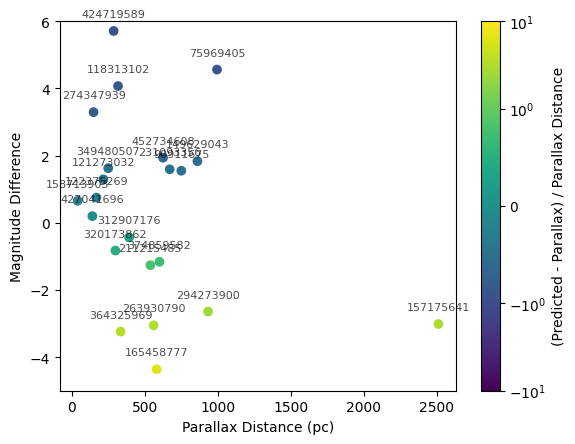

0.6052625376843843
-0.27553559006081146


In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.scatter(df['Dist'], df['diff'], c=((df['calc_d'] - df['Dist'])/df['Dist']), norm=colors.SymLogNorm(linthresh=1, linscale=1, 
                                           vmin=-10, vmax=10))
cbar = plt.colorbar()
cbar.ax.set_ylabel('(Predicted - Parallax) / Parallax Distance')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df.iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.ylim(-5, 6)
plt.show()

print(((df['calc_d'] - df['Dist'])/df['Dist']).mean())
print(((df['calc_d'] - df['Dist'])/df['Dist']).median())

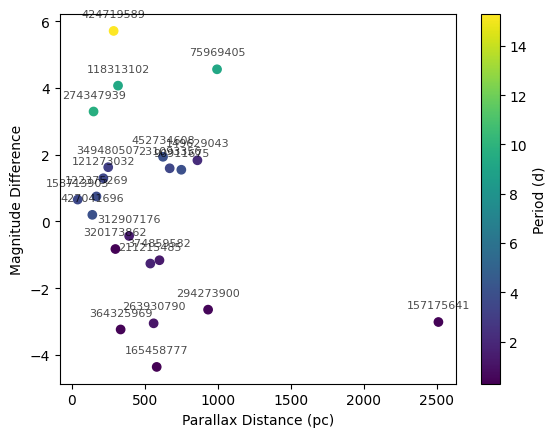

In [9]:
plt.scatter(df['Dist'], df['diff'], c=(df['Period']))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Period (d)')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df.iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.show()

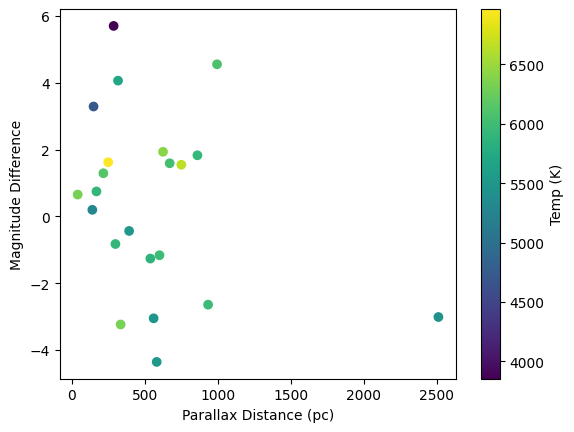

In [10]:
plt.scatter(df['Dist'], df['diff'], c=(df['Ballesteros T']))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Temp (K)')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')
plt.show()

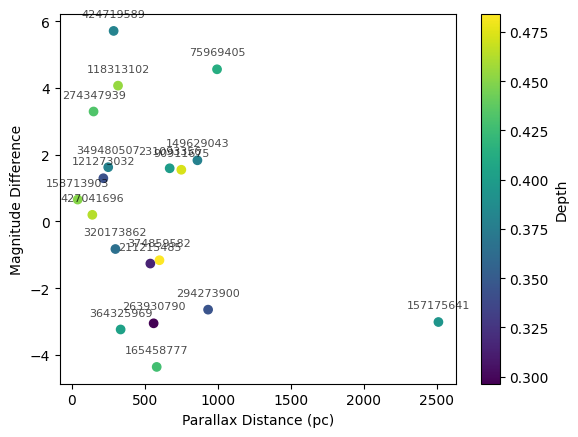

In [11]:
plt.scatter(df['Dist'][df['depth'] <= 0.5], df['diff'][df['depth'] <= 0.5], c=(df['depth'][df['depth'] <= 0.5]))
cbar = plt.colorbar()
cbar.ax.set_ylabel('Depth')
plt.xlabel('Parallax Distance (pc)')
plt.ylabel('Magnitude Difference')

for i, row in df[df['depth'] < 0.5].iterrows():
    plt.annotate(
        row['Target'],                      # The text to display
        (row['Dist'], row['diff']),         # Coordinates of the point
        textcoords="offset points",         # How to position the text
        xytext=(0, 10),                     # Distance from text to point (x,y)
        ha='center',                        # Horizontal alignment
        fontsize=8,                         # Smaller font for readability
        alpha=0.7                           # Slight transparency
    )

plt.show()